In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 연봉데이터 로딩, 전처리, EDA, Feature Engineering
# modeling, 성능 검증, 하이퍼파라미터 튜닝

# 기본모델: DecisionTree  - 성능 기준
# 배깅, 부스팅, 랜덤배깅 모델 튜닝

## 분석목적: 학력, 교육연수, 혼인상태, 직업정보가 있는 연봉데이터셋을 이용해 연봉 예측하기
## 연봉이 5만달러 이상인지 아닌지

* age: 나이
* workclass: 고용형태
* education: 학력
* education-num: 교육연수
* marital-status: 혼인상태
* occupation: 직업
* relationship: 가족관계
* race: 인종
* sex: 성별
* capital-gain: 자산증가
* capital-loss: 자산감소
* hours-per-week: 주당 노동 시간
* native-country: 본국
* class: 연봉구분 - target(분석대상)

In [2]:
data = pd.read_csv("https://raw.githubusercontent.com/haram4th/ADsP/main/salary2.csv")
data.head()

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       46043 non-null  object
 2   education       48842 non-null  object
 3   education-num   48842 non-null  int64 
 4   marital-status  48842 non-null  object
 5   occupation      46033 non-null  object
 6   relationship    48842 non-null  object
 7   race            48842 non-null  object
 8   sex             48842 non-null  object
 9   capital-gain    48842 non-null  int64 
 10  capital-loss    48842 non-null  int64 
 11  hours-per-week  48842 non-null  int64 
 12  native-country  47985 non-null  object
 13  class           48842 non-null  object
dtypes: int64(5), object(9)
memory usage: 5.2+ MB


In [4]:
data.describe(include='all')

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
count,48842.000000,46043,48842,48842.000000,48842,46033,48842,48842,48842,48842.000000,48842.000000,48842.000000,47985,48842
unique,NaN,8,16,NaN,7,14,6,5,2,NaN,NaN,NaN,41,2
top,NaN,Private,HS-grad,NaN,Married-civ-spouse,Prof-specialty,Husband,White,Male,NaN,NaN,NaN,United-States,<=50K
freq,NaN,33906,15784,NaN,22379,6172,19716,41762,32650,NaN,NaN,NaN,43832,37155
mean,38.643585,NaN,NaN,10.078089,NaN,NaN,NaN,NaN,NaN,1079.067626,87.502314,40.422382,NaN,NaN
std,13.710510,NaN,NaN,2.570973,NaN,NaN,NaN,NaN,NaN,7452.019058,403.004552,12.391444,NaN,NaN
min,17.000000,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,1.000000,NaN,NaN
25%,28.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
50%,37.000000,NaN,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
75%,48.000000,NaN,NaN,12.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,45.000000,NaN,NaN


# 1. 결측값 처리

In [5]:
data.isna().sum()

age                  0
workclass         2799
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
class                0
dtype: int64

In [6]:
data.isna().mean() * 100

age               0.000000
workclass         5.730724
education         0.000000
education-num     0.000000
marital-status    0.000000
occupation        5.751198
relationship      0.000000
race              0.000000
sex               0.000000
capital-gain      0.000000
capital-loss      0.000000
hours-per-week    0.000000
native-country    1.754637
class             0.000000
dtype: float64

In [7]:
data['workclass'].unique()

array([' Private', ' Local-gov', nan, ' Self-emp-not-inc', ' Federal-gov',
       ' State-gov', ' Self-emp-inc', ' Without-pay', ' Never-worked'],
      dtype=object)

In [8]:
# 나이가 20세 미만
# 미혼모, 미혼부
# 별거중, 멀리 떨어져 있음
data[data['workclass'] == ' Never-worked']

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
8785,17,Never-worked,11th,7,Never-married,NaN,Own-child,Black,Female,0,0,20,United-States,<=50K
11607,20,Never-worked,HS-grad,9,Married-spouse-absent,NaN,Other-relative,White,Male,0,0,35,United-States,<=50K
13898,18,Never-worked,11th,7,Never-married,NaN,Own-child,White,Male,0,0,35,United-States,<=50K
21642,18,Never-worked,10th,6,Never-married,NaN,Own-child,White,Male,0,0,40,United-States,<=50K
27126,23,Never-worked,7th-8th,4,Divorced,NaN,Not-in-family,White,Male,0,0,35,United-States,<=50K
31053,17,Never-worked,10th,6,Never-married,NaN,Own-child,White,Male,0,0,30,United-States,<=50K
36618,18,Never-worked,11th,7,Never-married,NaN,Own-child,White,Female,0,0,10,United-States,<=50K
39513,20,Never-worked,Some-college,10,Never-married,NaN,Own-child,Black,Male,0,0,40,United-States,<=50K
48585,30,Never-worked,HS-grad,9,Married-civ-spouse,NaN,Wife,Black,Female,0,0,40,United-States,<=50K
48595,18,Never-worked,Some-college,10,Never-married,NaN,Own-child,White,Male,0,0,4,United-States,<=50K


In [9]:
data.loc[data['workclass'] == ' Never-worked', 'occupation'] = 'part-time'

In [10]:
data[data['workclass'] == ' Without-pay']

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
2957,19,Without-pay,HS-grad,9,Never-married,Other-service,Own-child,White,Male,0,0,10,United-States,<=50K
3177,74,Without-pay,7th-8th,4,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,20,United-States,<=50K
6466,51,Without-pay,Assoc-acdm,12,Married-civ-spouse,Sales,Husband,White,Male,0,0,45,United-States,<=50K
8903,64,Without-pay,HS-grad,9,Married-civ-spouse,Handlers-cleaners,Husband,White,Male,0,0,60,United-States,>50K
10647,50,Without-pay,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Own-child,White,Female,0,1887,40,United-States,>50K
13836,39,Without-pay,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,40,United-States,<=50K
14034,27,Without-pay,HS-grad,9,Never-married,Farming-fishing,Own-child,White,Female,0,0,40,United-States,<=50K
18182,65,Without-pay,7th-8th,4,Widowed,Farming-fishing,Unmarried,White,Female,0,0,50,United-States,<=50K
25538,19,Without-pay,HS-grad,9,Never-married,Farming-fishing,Own-child,White,Male,0,0,20,United-States,<=50K
31814,21,Without-pay,HS-grad,9,Never-married,Craft-repair,Own-child,Black,Male,0,0,40,United-States,<=50K


In [11]:
data[data['workclass'].isna() == True]

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
4,18,NaN,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K
6,29,NaN,HS-grad,9,Never-married,NaN,Unmarried,Black,Male,0,0,40,United-States,<=50K
13,58,NaN,HS-grad,9,Married-civ-spouse,NaN,Husband,White,Male,0,0,35,United-States,<=50K
22,72,NaN,7th-8th,4,Divorced,NaN,Not-in-family,White,Female,0,0,6,United-States,<=50K
35,65,NaN,HS-grad,9,Married-civ-spouse,NaN,Husband,White,Male,0,0,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48811,35,NaN,Bachelors,13,Married-civ-spouse,NaN,Wife,White,Female,0,0,55,United-States,>50K
48812,30,NaN,Bachelors,13,Never-married,NaN,Not-in-family,Asian-Pac-Islander,Female,0,0,99,United-States,<=50K
48820,71,NaN,Doctorate,16,Married-civ-spouse,NaN,Husband,White,Male,0,0,10,United-States,>50K
48822,41,NaN,HS-grad,9,Separated,NaN,Not-in-family,Black,Female,0,0,32,United-States,<=50K


In [12]:
data.loc[data['workclass'].isna() == True, 'workclass'] = 'part-time'

In [13]:
data['occupation'] = data['occupation'].fillna('part-time')

In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       48842 non-null  object
 2   education       48842 non-null  object
 3   education-num   48842 non-null  int64 
 4   marital-status  48842 non-null  object
 5   occupation      48842 non-null  object
 6   relationship    48842 non-null  object
 7   race            48842 non-null  object
 8   sex             48842 non-null  object
 9   capital-gain    48842 non-null  int64 
 10  capital-loss    48842 non-null  int64 
 11  hours-per-week  48842 non-null  int64 
 12  native-country  47985 non-null  object
 13  class           48842 non-null  object
dtypes: int64(5), object(9)
memory usage: 5.2+ MB


In [15]:
data.isna().sum()

age                 0
workclass           0
education           0
education-num       0
marital-status      0
occupation          0
relationship        0
race                0
sex                 0
capital-gain        0
capital-loss        0
hours-per-week      0
native-country    857
class               0
dtype: int64

In [16]:
data = data.dropna()

In [17]:
data.isna().sum()

age               0
workclass         0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
class             0
dtype: int64

In [18]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 47985 entries, 0 to 48841
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             47985 non-null  int64 
 1   workclass       47985 non-null  object
 2   education       47985 non-null  object
 3   education-num   47985 non-null  int64 
 4   marital-status  47985 non-null  object
 5   occupation      47985 non-null  object
 6   relationship    47985 non-null  object
 7   race            47985 non-null  object
 8   sex             47985 non-null  object
 9   capital-gain    47985 non-null  int64 
 10  capital-loss    47985 non-null  int64 
 11  hours-per-week  47985 non-null  int64 
 12  native-country  47985 non-null  object
 13  class           47985 non-null  object
dtypes: int64(5), object(9)
memory usage: 5.5+ MB


카테고리 변수들의 자료에 공백이 있어 공백을 제거

In [19]:
cols = list(data.columns)
cols

['age',
 'workclass',
 'education',
 'education-num',
 'marital-status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'capital-gain',
 'capital-loss',
 'hours-per-week',
 'native-country',
 'class']

In [20]:
data['workclass'].apply(lambda x: x.strip())

0             Private
1             Private
2           Local-gov
3             Private
4           part-time
             ...     
48837         Private
48838         Private
48839         Private
48840         Private
48841    Self-emp-inc
Name: workclass, Length: 47985, dtype: object

In [21]:
for col in cols:
    if data[col].dtype == 'O':
        data[col] = data[col].apply(lambda x: x.strip())
    

In [22]:
for col in cols:
    if data[col].dtype == 'O':
        print(col, data[col].unique())

workclass ['Private' 'Local-gov' 'part-time' 'Self-emp-not-inc' 'Federal-gov'
 'State-gov' 'Self-emp-inc' 'Without-pay' 'Never-worked']
education ['11th' 'HS-grad' 'Assoc-acdm' 'Some-college' '10th' 'Prof-school'
 '7th-8th' 'Bachelors' 'Masters' '5th-6th' 'Assoc-voc' '9th' 'Doctorate'
 '12th' '1st-4th' 'Preschool']
marital-status ['Never-married' 'Married-civ-spouse' 'Widowed' 'Divorced' 'Separated'
 'Married-spouse-absent' 'Married-AF-spouse']
occupation ['Machine-op-inspct' 'Farming-fishing' 'Protective-serv' 'part-time'
 'Other-service' 'Prof-specialty' 'Craft-repair' 'Adm-clerical'
 'Exec-managerial' 'Tech-support' 'Sales' 'Priv-house-serv'
 'Transport-moving' 'Handlers-cleaners' 'Armed-Forces']
relationship ['Own-child' 'Husband' 'Not-in-family' 'Unmarried' 'Wife' 'Other-relative']
race ['Black' 'White' 'Other' 'Amer-Indian-Eskimo' 'Asian-Pac-Islander']
sex ['Male' 'Female']
native-country ['United-States' 'Peru' 'Guatemala' 'Mexico' 'Dominican-Republic'
 'Ireland' 'Germany' 'Phil

# 이상치 탐지

In [23]:
search_outlier = data.describe()

In [24]:
search_outlier.loc['75%', :] + 1.5 * (search_outlier.loc['75%', :] - search_outlier.loc['25%', :])

age               78.0
education-num     16.5
capital-gain       0.0
capital-loss       0.0
hours-per-week    52.5
dtype: float64

In [25]:
search_outlier

,age,education-num,capital-gain,capital-loss,hours-per-week
count,47985.000000,47985.000000,47985.000000,47985.000000,47985.000000
mean,38.641284,10.067229,1067.032093,87.370553,40.411483
std,13.729622,2.560534,7373.256663,402.681462,12.391073
min,17.000000,1.000000,0.000000,0.000000,1.000000
25%,28.000000,9.000000,0.000000,0.000000,40.000000
50%,37.000000,10.000000,0.000000,0.000000,40.000000
75%,48.000000,12.000000,0.000000,0.000000,45.000000
max,90.000000,16.000000,99999.000000,4356.000000,99.000000


* capital-gain	capital-loss 히스토그램 그리기
* hours-per-week 이상값을 가진 데이터 찾아보기

In [26]:
data

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,part-time,Some-college,10,Never-married,part-time,Own-child,White,Female,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [27]:
data[data['age'] > 78]

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
193,79,part-time,7th-8th,4,Widowed,part-time,Not-in-family,White,Male,0,0,40,United-States,<=50K
234,80,Self-emp-not-inc,HS-grad,9,Married-civ-spouse,Other-service,Husband,White,Male,0,0,30,United-States,<=50K
899,90,Private,Assoc-acdm,12,Married-civ-spouse,Sales,Husband,White,Male,0,1825,50,United-States,>50K
926,79,part-time,Masters,14,Never-married,part-time,Not-in-family,White,Female,0,0,23,United-States,<=50K
951,80,Private,HS-grad,9,Married-spouse-absent,Machine-op-inspct,Not-in-family,White,Female,0,0,16,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48136,82,Self-emp-not-inc,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,20,United-States,<=50K
48558,90,Private,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,25,United-States,<=50K
48648,90,Local-gov,7th-8th,4,Married-civ-spouse,Protective-serv,Husband,White,Male,2653,0,40,United-States,<=50K
48740,85,Private,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,3,Poland,<=50K


In [28]:
data['age'] = data['age'].apply(lambda x: 78 if x > 78 else x)

In [38]:
data[data['age'] == 78]

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
193,78,part-time,7th-8th,4,Widowed,part-time,Not-in-family,White,Male,0,0,40,United-States,<=50K
234,78,Self-emp-not-inc,HS-grad,9,Married-civ-spouse,Other-service,Husband,White,Male,0,0,30,United-States,<=50K
899,78,Private,Assoc-acdm,12,Married-civ-spouse,Sales,Husband,White,Male,0,1825,50,United-States,>50K
926,78,part-time,Masters,14,Never-married,part-time,Not-in-family,White,Female,0,0,23,United-States,<=50K
951,78,Private,HS-grad,9,Married-spouse-absent,Machine-op-inspct,Not-in-family,White,Female,0,0,16,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48136,78,Self-emp-not-inc,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,20,United-States,<=50K
48558,78,Private,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,25,United-States,<=50K
48648,78,Local-gov,7th-8th,4,Married-civ-spouse,Protective-serv,Husband,White,Male,2653,0,40,United-States,<=50K
48740,78,Private,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,3,Poland,<=50K


In [33]:
data[data['education-num'] > 16.5]

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class


In [34]:
data[data['hours-per-week'] > 52.5]

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
25,45,Self-emp-not-inc,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,7298,0,90,United-States,>50K
27,23,Private,HS-grad,9,Separated,Machine-op-inspct,Unmarried,Black,Male,0,0,54,United-States,<=50K
29,32,Self-emp-not-inc,Some-college,10,Never-married,Prof-specialty,Not-in-family,White,Male,0,0,60,United-States,<=50K
53,22,Private,HS-grad,9,Never-married,Other-service,Not-in-family,White,Male,14084,0,60,United-States,>50K
54,38,Private,9th,5,Married-spouse-absent,Exec-managerial,Not-in-family,White,Male,0,0,54,Mexico,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48811,35,part-time,Bachelors,13,Married-civ-spouse,part-time,Wife,White,Female,0,0,55,United-States,>50K
48812,30,part-time,Bachelors,13,Never-married,part-time,Not-in-family,Asian-Pac-Islander,Female,0,0,99,United-States,<=50K
48813,34,Private,Doctorate,16,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,60,United-States,>50K
48817,34,Private,Bachelors,13,Never-married,Exec-managerial,Not-in-family,White,Female,0,0,55,United-States,>50K


In [35]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 47985 entries, 0 to 48841
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             47985 non-null  int64 
 1   workclass       47985 non-null  object
 2   education       47985 non-null  object
 3   education-num   47985 non-null  int64 
 4   marital-status  47985 non-null  object
 5   occupation      47985 non-null  object
 6   relationship    47985 non-null  object
 7   race            47985 non-null  object
 8   sex             47985 non-null  object
 9   capital-gain    47985 non-null  int64 
 10  capital-loss    47985 non-null  int64 
 11  hours-per-week  47985 non-null  int64 
 12  native-country  47985 non-null  object
 13  class           47985 non-null  object
dtypes: int64(5), object(9)
memory usage: 5.5+ MB


In [39]:
data['hours-per-week'] = data['hours-per-week'].apply(lambda x: 52 if x > 52 else x)

In [40]:
data[data['hours-per-week'] == 52]

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
25,45,Self-emp-not-inc,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,7298,0,52,United-States,>50K
27,23,Private,HS-grad,9,Separated,Machine-op-inspct,Unmarried,Black,Male,0,0,52,United-States,<=50K
29,32,Self-emp-not-inc,Some-college,10,Never-married,Prof-specialty,Not-in-family,White,Male,0,0,52,United-States,<=50K
53,22,Private,HS-grad,9,Never-married,Other-service,Not-in-family,White,Male,14084,0,52,United-States,>50K
54,38,Private,9th,5,Married-spouse-absent,Exec-managerial,Not-in-family,White,Male,0,0,52,Mexico,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48811,35,part-time,Bachelors,13,Married-civ-spouse,part-time,Wife,White,Female,0,0,52,United-States,>50K
48812,30,part-time,Bachelors,13,Never-married,part-time,Not-in-family,Asian-Pac-Islander,Female,0,0,52,United-States,<=50K
48813,34,Private,Doctorate,16,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,52,United-States,>50K
48817,34,Private,Bachelors,13,Never-married,Exec-managerial,Not-in-family,White,Female,0,0,52,United-States,>50K


# EDA 탐색적 데이터 분석

In [ ]:
분석목적: 학력, 교육연수, 혼인상태, 직업정보가 있는 연봉데이터셋을 이용해 연봉 예측하기

In [41]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 47985 entries, 0 to 48841
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             47985 non-null  int64 
 1   workclass       47985 non-null  object
 2   education       47985 non-null  object
 3   education-num   47985 non-null  int64 
 4   marital-status  47985 non-null  object
 5   occupation      47985 non-null  object
 6   relationship    47985 non-null  object
 7   race            47985 non-null  object
 8   sex             47985 non-null  object
 9   capital-gain    47985 non-null  int64 
 10  capital-loss    47985 non-null  int64 
 11  hours-per-week  47985 non-null  int64 
 12  native-country  47985 non-null  object
 13  class           47985 non-null  object
dtypes: int64(5), object(9)
memory usage: 5.5+ MB


In [42]:
data.head()

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,part-time,Some-college,10,Never-married,part-time,Own-child,White,Female,0,0,30,United-States,<=50K


In [47]:
data.groupby('age')['class'].value_counts()

age  class
17   <=50K     592
18   <=50K     851
19   <=50K    1044
     >50K        3
20   <=50K    1098
              ... 
76   >50K        7
77   <=50K      46
     >50K        8
78   <=50K     202
     >50K       43
Name: count, Length: 122, dtype: int64

In [43]:
data['workclass'].unique()

array(['Private', 'Local-gov', 'part-time', 'Self-emp-not-inc',
       'Federal-gov', 'State-gov', 'Self-emp-inc', 'Without-pay',
       'Never-worked'], dtype=object)

<Axes: xlabel='workclass,class'>

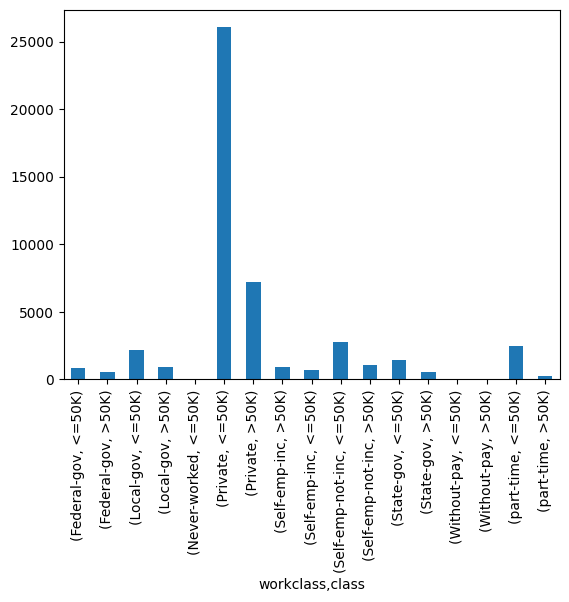

In [46]:
data.groupby('workclass')['class'].value_counts().plot(kind='bar')

<Axes: xlabel='education,class'>

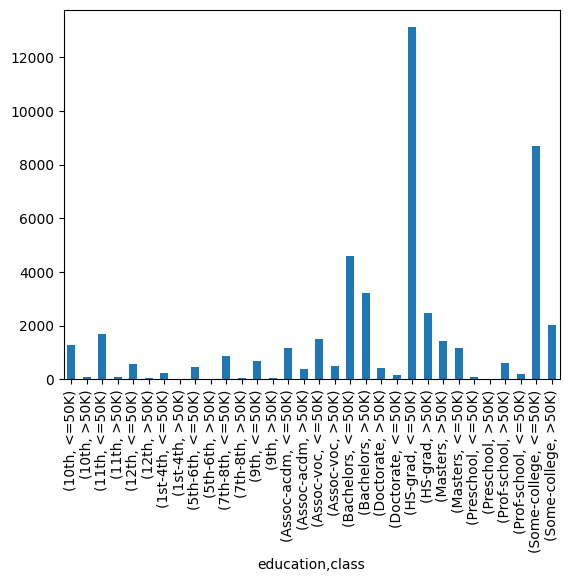

In [65]:
data.groupby('education')['class'].value_counts().plot(kind='bar')

In [66]:
data.groupby('marital-status')['class'].value_counts()

marital-status         class
Divorced               <=50K     5897
                       >50K       664
Married-AF-spouse      <=50K       23
                       >50K        14
Married-civ-spouse     <=50K    12174
                       >50K      9797
Married-spouse-absent  <=50K      540
                       >50K        55
Never-married          <=50K    15105
                       >50K       711
Separated              <=50K     1408
                       >50K        99
Widowed                <=50K     1371
                       >50K       127
Name: count, dtype: int64

<Axes: xlabel='marital-status,class'>

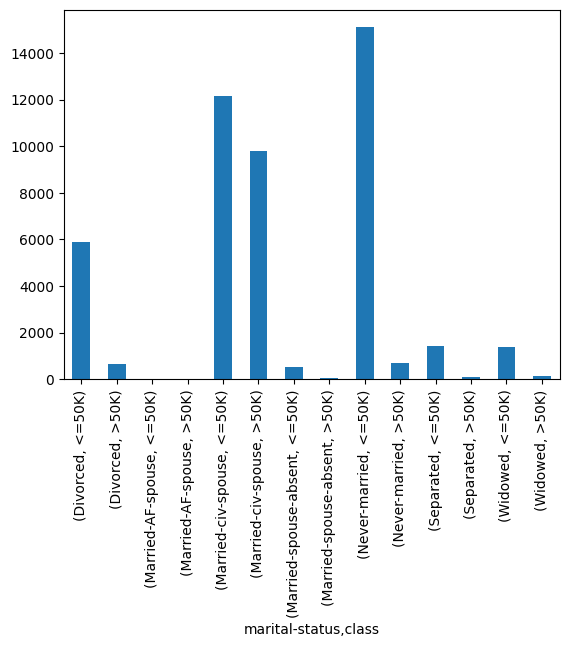

In [64]:
data.groupby('marital-status')['class'].value_counts().plot(kind='bar')

In [67]:
data.groupby('occupation')['class'].value_counts()

occupation         class
Adm-clerical       <=50K    4784
                   >50K      756
Armed-Forces       <=50K      10
                   >50K        4
Craft-repair       <=50K    4665
                   >50K     1355
Exec-managerial    <=50K    3117
                   >50K     2867
Farming-fishing    <=50K    1308
                   >50K      172
Handlers-cleaners  <=50K    1911
                   >50K      135
Machine-op-inspct  <=50K    2605
                   >50K      365
Other-service      <=50K    4612
                   >50K      196
Priv-house-serv    <=50K     229
                   >50K        3
Prof-specialty     <=50K    3304
                   >50K     2704
Protective-serv    <=50K     669
                   >50K      307
Sales              <=50K    3953
                   >50K     1455
Tech-support       <=50K    1009
                   >50K      411
Transport-moving   <=50K    1838
                   >50K      478
part-time          <=50K    2504
                  

<Axes: xlabel='occupation,class'>

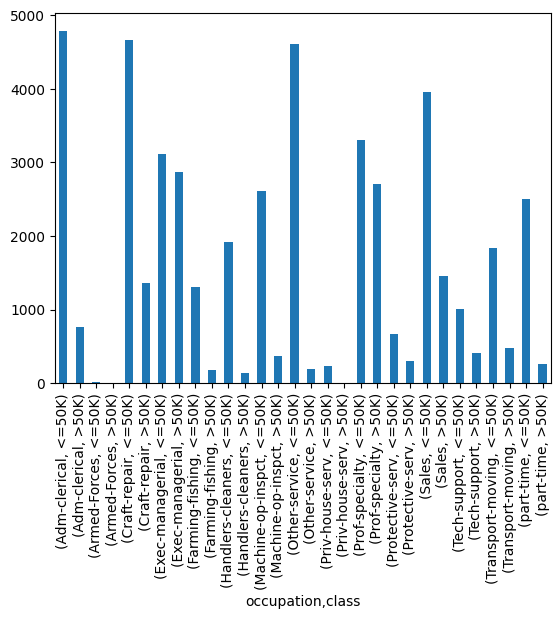

In [68]:
data.groupby('occupation')['class'].value_counts().plot(kind='bar')

In [62]:
edu_values = list(data['education'].unique())
edu_values

['11th',
 'HS-grad',
 'Assoc-acdm',
 'Some-college',
 '10th',
 'Prof-school',
 '7th-8th',
 'Bachelors',
 'Masters',
 '5th-6th',
 'Assoc-voc',
 '9th',
 'Doctorate',
 '12th',
 '1st-4th',
 'Preschool']

In [ ]:
for i in edu_values:
    data[i]

In [69]:
def educations(x):
    if x == 'Preschool':
        return 'P'
    elif (x == '1st-4th') | (x == '5th-6th'):
        return "E"
    elif (x == '7th-8th') | (x == '9th'):
        return "M"
    elif (x == '10th') | (x == '11th') | (x == '12th') | (x == 'HS-grad'):
        return "H"
    elif (x == 'Some-college') | (x == 'Assoc-acdm') | (x =='Assoc-voc') | (x == 'Bachelors'):
        return "U"
    elif (x == 'Masters') | (x == 'Doctorate') | (x ==  'Prof-school'):
        return "G"

In [70]:
data['education'] = data['education'].apply(educations)

In [72]:
data.groupby('education')['class'].value_counts()

education  class
E          <=50K      698
           >50K        32
G          >50K      2436
           <=50K     1513
H          <=50K    16690
           >50K      2703
M          <=50K     1578
           >50K        98
P          <=50K       81
           >50K         1
U          <=50K    15958
           >50K      6197
Name: count, dtype: int64

<Axes: xlabel='education,class'>

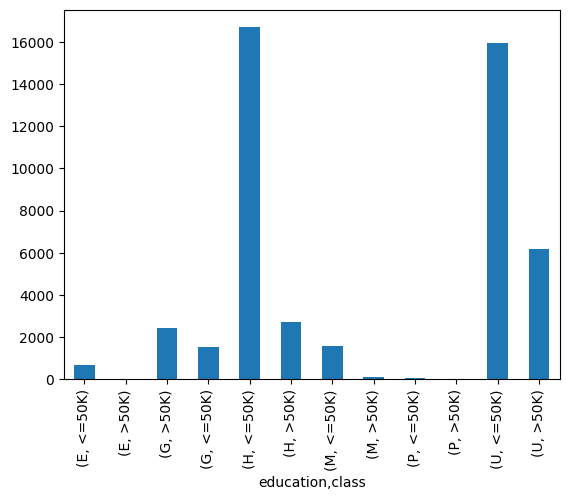

In [71]:
data.groupby('education')['class'].value_counts().plot(kind='bar')

In [73]:
def martial_statuses(x):
    if 'Married-' in x:
        return 'Married'
    else:
        return 'Alone'

In [74]:
data['marital-status'] = data['marital-status'].apply(martial_statuses)

<Axes: xlabel='marital-status,class'>

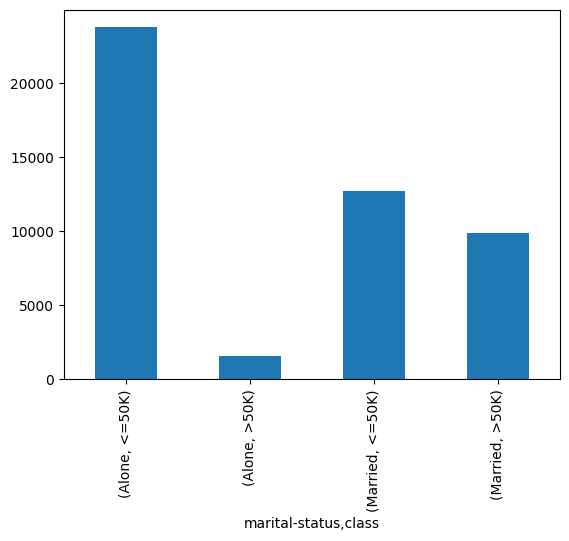

In [75]:
data.groupby('marital-status')['class'].value_counts().plot(kind='bar')

In [76]:
def occupations(x):
    if x == 'Farming-fishing':
        return 'F'
    elif (x == 'Armed-Forces') | (x == 'Protective-serv'):
        return "P"
    elif (x == 'Prof-specialty') | (x == 'Exec-managerial') | (x == 'Adm-clerical') | (x == 'Tech-support') | (x == 'Sales'):
        return "W"
    else:
        return "B"

In [77]:
data['occupation'] = data['occupation'].apply(occupations)

<Axes: xlabel='occupation,class'>

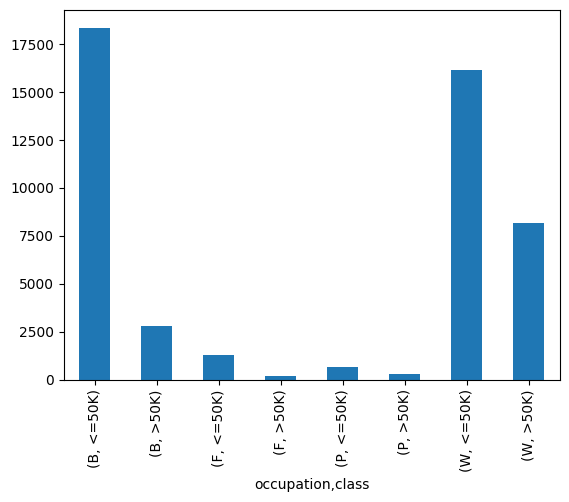

In [78]:
data.groupby('occupation')['class'].value_counts().plot(kind='bar')

In [79]:
data1 = data.copy()

In [80]:
data1

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,H,7,Alone,B,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,H,9,Married,F,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,U,12,Married,P,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,U,10,Married,B,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,part-time,U,10,Alone,B,Own-child,White,Female,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,U,12,Married,W,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,H,9,Married,B,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,H,9,Alone,W,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,H,9,Alone,W,Own-child,White,Male,0,0,20,United-States,<=50K


In [82]:
data1.columns

Index(['age', 'workclass', 'education', 'education-num', 'marital-status',
       'occupation', 'relationship', 'race', 'sex', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country', 'class'],
      dtype='object')

In [84]:
data1 = data1.drop(['age', 'workclass', 'capital-gain', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country'], axis=1)

In [85]:
data1

,education,education-num,marital-status,occupation,class
0,H,7,Alone,B,<=50K
1,H,9,Married,F,<=50K
2,U,12,Married,P,>50K
3,U,10,Married,B,>50K
4,U,10,Alone,B,<=50K
...,...,...,...,...,...
48837,U,12,Married,W,<=50K
48838,H,9,Married,B,>50K
48839,H,9,Alone,W,<=50K
48840,H,9,Alone,W,<=50K


In [88]:
data1 = pd.get_dummies(data1, columns=['education', 'marital-status', 'occupation'], drop_first=True)

In [89]:
data1

,education-num,class,education_G,education_H,education_M,education_P,education_U,marital-status_Married,occupation_F,occupation_P,occupation_W
0,7,<=50K,False,True,False,False,False,False,False,False,False
1,9,<=50K,False,True,False,False,False,True,True,False,False
2,12,>50K,False,False,False,False,True,True,False,True,False
3,10,>50K,False,False,False,False,True,True,False,False,False
4,10,<=50K,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
48837,12,<=50K,False,False,False,False,True,True,False,False,True
48838,9,>50K,False,True,False,False,False,True,False,False,False
48839,9,<=50K,False,True,False,False,False,False,False,False,True
48840,9,<=50K,False,True,False,False,False,False,False,False,True


In [110]:
data1 = pd.get_dummies(data1, columns=['class'], drop_first=True)
data1

,education-num,education_G,education_H,education_M,education_P,education_U,marital-status_Married,occupation_F,occupation_P,occupation_W,class_>50K
0,7,False,True,False,False,False,False,False,False,False,False
1,9,False,True,False,False,False,True,True,False,False,False
2,12,False,False,False,False,True,True,False,True,False,True
3,10,False,False,False,False,True,True,False,False,False,True
4,10,False,False,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
48837,12,False,False,False,False,True,True,False,False,True,False
48838,9,False,True,False,False,False,True,False,False,False,True
48839,9,False,True,False,False,False,False,False,False,True,False
48840,9,False,True,False,False,False,False,False,False,True,False


In [113]:
X = data1.drop('class_>50K', axis=1)
y = data1['class_>50K']

In [95]:
from sklearn.tree import plot_tree

In [99]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

In [92]:
from sklearn.ensemble import BaggingClassifier

In [104]:
from sklearn.metrics import accuracy_score, classification_report

In [102]:
X_train.columns

Index(['education-num', 'education_G', 'education_H', 'education_M',
       'education_P', 'education_U', 'marital-status_Married', 'occupation_F',
       'occupation_P', 'occupation_W'],
      dtype='object')

In [115]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=8)

In [116]:
for ts in range(1, 10):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=ts/10, random_state=8)
    dtc = DecisionTreeClassifier()
    dtc.fit(X_train, y_train)
    pred = dtc.predict(X_test)
    print(ts/10, accuracy_score(y_test, pred))
    print(ts/10, classification_report(y_test, pred))

0.1 0.8245467805792873
0.1               precision    recall  f1-score   support

       False       0.87      0.91      0.89      3706
        True       0.64      0.53      0.58      1093

    accuracy                           0.82      4799
   macro avg       0.75      0.72      0.73      4799
weighted avg       0.82      0.82      0.82      4799

0.2 0.826716682296551
0.2               precision    recall  f1-score   support

       False       0.87      0.91      0.89      7337
        True       0.66      0.54      0.60      2260

    accuracy                           0.83      9597
   macro avg       0.76      0.73      0.74      9597
weighted avg       0.82      0.83      0.82      9597

0.3 0.8273131425395943
0.3               precision    recall  f1-score   support

       False       0.87      0.91      0.89     10989
        True       0.66      0.55      0.60      3407

    accuracy                           0.83     14396
   macro avg       0.77      0.73      0.75     

In [117]:
for i in range(1, 20):
    dtc = DecisionTreeClassifier(max_depth=i, random_state=8)
    dtc.fit(X_train, y_train)
    pred = dtc.predict(X_test)
    print(i, accuracy_score(y_test, pred))
    print(i, classification_report(y_test, pred))

1 0.7607844953342441
1               precision    recall  f1-score   support

       False       0.76      1.00      0.86     32856
        True       0.00      0.00      0.00     10331

    accuracy                           0.76     43187
   macro avg       0.38      0.50      0.43     43187
weighted avg       0.58      0.76      0.66     43187

2 0.8198531965637808
2               precision    recall  f1-score   support

       False       0.84      0.95      0.89     32856
        True       0.71      0.41      0.52     10331

    accuracy                           0.82     43187
   macro avg       0.78      0.68      0.71     43187
weighted avg       0.81      0.82      0.80     43187

3 0.8207794012086971
3               precision    recall  f1-score   support

       False       0.83      0.96      0.89     32856
        True       0.74      0.39      0.51     10331

    accuracy                           0.82     43187
   macro avg       0.78      0.67      0.70     43187
weigh

C:\Users\5-25\miniforge3\envs\fintech\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\5-25\miniforge3\envs\fintech\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\5-25\miniforge3\envs\fintech\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


5               precision    recall  f1-score   support

       False       0.87      0.91      0.89     32856
        True       0.66      0.55      0.60     10331

    accuracy                           0.82     43187
   macro avg       0.76      0.73      0.74     43187
weighted avg       0.82      0.82      0.82     43187

6 0.8240674276981499
6               precision    recall  f1-score   support

       False       0.87      0.91      0.89     32856
        True       0.66      0.55      0.60     10331

    accuracy                           0.82     43187
   macro avg       0.76      0.73      0.74     43187
weighted avg       0.82      0.82      0.82     43187

7 0.823534860027323
7               precision    recall  f1-score   support

       False       0.87      0.91      0.89     32856
        True       0.66      0.55      0.60     10331

    accuracy                           0.82     43187
   macro avg       0.76      0.73      0.74     43187
weighted avg       0.82    

In [118]:
bc = BaggingClassifier(n_estimators=80, n_jobs=7, random_state=8)
bc.fit(X_train, y_train)
pred = bc.predict(X_test)
print(accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

0.822307638872809
              precision    recall  f1-score   support

       False       0.87      0.91      0.89     32856
        True       0.65      0.55      0.60     10331

    accuracy                           0.82     43187
   macro avg       0.76      0.73      0.74     43187
weighted avg       0.81      0.82      0.82     43187



In [106]:
from xgboost import XGBClassifier

In [119]:
xgb = XGBClassifier(n_estimators=2000, max_depth=1, learning_rate=0.7, random_state=8, n_jobs=-1)
xgb.fit(X_train, y_train)
pred = xgb.predict(X_test)
print(accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

0.8202236784217473
              precision    recall  f1-score   support

       False       0.84      0.94      0.89     32856
        True       0.69      0.45      0.55     10331

    accuracy                           0.82     43187
   macro avg       0.77      0.69      0.72     43187
weighted avg       0.81      0.82      0.81     43187



In [120]:
from lightgbm import LGBMClassifier

In [121]:
lgbm = LGBMClassifier(n_estimators=2000, learning_rate=0.1, random_state=8, n_jobs=-1)
lgbm.fit(X_train, y_train)
pred = lgbm.predict(X_test)
print(accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

[LightGBM] [Info] Number of positive: 1136, number of negative: 3662
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000356 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 33
[LightGBM] [Info] Number of data points in the train set: 4798, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.236765 -> initscore=-1.170496
[LightGBM] [Info] Start training from score -1.170496
0.8236969458401834
              precision    recall  f1-score   support

       False       0.87      0.91      0.89     32856
        True       0.66      0.55      0.60     10331

    accuracy                           0.82     43187
   macro avg       0.76      0.73      0.74     43187
weighted avg       0.82      0.82      0.82     43187

